# Klassifitseerimine

Klassifitseerimine tähendab objekti liigi ennustamist vastavalt klassifikaatorile st arvutuslikule mudelile, mis väljastab kas objekti liigi või tõenäosusliku ennustuse. Klassifikaatorid treenitakse objektide peal, mille klass on teada, kasutades klassifikaatori tüübile sobivaid treeningmeetodeid.

Sisukord:
* [Andmestik Iris](#Iris)
* [Ülesanne 4.1](#4_1)
* [Klassifitseerimismeetodeid: pertseptronid, logistiline regressioon, tugivektor masinad ja otsustuspuud](#Meetodeid)
* [Ülesanne 4.2](#4_2)


# Andmestik *Iris*

See sissejuhatav näide, mis annab lühiülevaate klassifitseerimisprotsessist, põhineb S.Raschka raamatu Python Machine Learning peatükil 3.


Mooduli *sklearn* alammoodul ```datasets``` sisaldab mitmeid näiteandmestike, mida on võimalik vastava ```load_<nimi>()``` funkstiooniga laadida. Tavaliselt laeme me oma andmestikke csv failidest, aga selles näites me seda funktsionaalsust ei vaatle. *Iris* andmestik sisaldab erinevate iiriste (lill) mõõtmistulemusi.

In [1]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()

Vaatame andmestiku kirjeldust (DESCR). 


In [2]:
print("\n",iris.DESCR)


 .. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:

Vaatame toorandmete maatriksit (data).

In [3]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

Vaatame klasside vektorit ja klasside 0, 1, 2 nimesid, vektori iga element vastab maatriksi reale.

In [4]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Omistame andmemaatriksi muutujale *X* ja klassivektori muutujale *y*.

In [6]:
X = iris.data
y = iris.target

Kuna me tahame kontrollida, kuidas meie ennustav mudel töötab uute andmetega, siis on õige jagada andmestik treening- (*X_train, y_train*) ja testandmeteks (*X_test, y_test*). Selle jaoks kasutame mooduli [model_selection](https://scikit-learn.org/stable/model_selection.html#model-selection) funktsiooni [train_test_split()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn.model_selection.train_test_split). Funktsiooni parameetreid määravad testandmete proportsiooni koguandmetest (30%) ja juhuarvude generaatori sisendmuutuja. 

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print("Treeningklassid:", y_train)
print("\nTestklassid:", y_test)

Treeningklassid: [1 2 2 2 2 1 2 1 1 2 2 2 2 1 2 1 0 2 1 1 1 1 2 0 0 2 1 0 0 1 0 2 1 0 1 2 1
 0 2 2 2 2 0 0 2 2 0 2 0 2 2 0 0 2 0 0 0 1 2 2 0 0 0 1 1 0 0 1 0 2 1 2 1 0
 2 0 2 0 0 2 0 2 1 1 1 2 2 1 1 0 1 2 2 0 1 1 1 1 0 0 0 2 1 2 0]

Testklassid: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0]


In [8]:
np.unique(y_test, return_counts=True)

(array([0, 1, 2]), array([16, 18, 11]))

Paljud masinõppe algoritmid vajavad optimaalseks tööks omaduste(atribuutide) väärtuste skaleerimist/normaliseerimist. Siin kasutame selleks eeltöötluseks  [preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing)  mooduli klassi [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler) (keskväärtus 0, ühikdispersioon). Seostame selle ```fit()``` meetodi abil ```X_train``` andmestikuga ja omistame transformeeritud ```X_train``` ja ```X_test``` andmestikud muutujatele ```X_train_std, X_test_std```.

In [9]:
import pandas as pd
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Nagu näha erineb standardhälve (std) veeruti oluliselt: 0.44 ... 1.76 ühikut.

In [10]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

std_df = pd.DataFrame(X_train_std, columns=iris.feature_names)
std_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.050000e+02,1.050000e+02,1.050000e+02,1.050000e+02
mean,2.816794e-15,-1.023520e-15,-3.573861e-16,2.749124e-17
std,1.004796e+00,1.004796e+00,1.004796e+00,1.004796e+00
min,-1.825788e+00,-2.378463e+00,-1.519284e+00,-1.452412e+00
25%,-9.090745e-01,-5.572150e-01,-1.240881e+00,-1.194805e+00
50%,-1.069499e-01,-1.019031e-01,3.181746e-01,9.322915e-02
75%,6.951746e-01,5.810647e-01,7.636190e-01,8.660497e-01
max,2.299424e+00,3.085280e+00,1.710188e+00,1.638870e+00


<a id=Pred></a>

Järgmiseks tekitame klassifitseeriva (ennustava) mudeli. Siin kasutame selleks pertseptronit (lihtne tehisnärvivõrk, klass __[Perceptron](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html)__). See osa tuleb mõne muu mudeli testimiseks, mida on [scikit-learn klassifitseerimise teemas](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) palju, üle kirjutada.

In [11]:
import sklearn
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

#predictive_model = Perceptron(max_iter=40, tol=0.001, eta0=0.1, random_state=0)
#predictive_model = LogisticRegression(solver='lbfgs') # actually a classification, not regression
#predictive_model = SVC(kernel='rbf') # Support Vector Classification. Tugivektor klassifitseerimine.
predictive_model = DecisionTreeClassifier()

Treenime ennustava mudeli meetodi ```fit()``` abil kasutades treeningandmeid (andmemaatriks, oodatavate klasside vektor).

In [12]:
predictive_model.fit(X_train_std, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

Leiame ennustused ```y_pred``` testandmete tarbeks kasutades meetodit ```predict()```.


In [13]:
y_pred = predictive_model.predict(X_test_std)
print(y_pred)

[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2 1 1 2 0 2 0 0]


Võrdleme ennustusi olemasolevate andmetega. Kasutame 
__[numpy massiivide](https://docs.scipy.org/doc/numpy/reference/generated/numpy.array.html)__  võrdlusoperaatorit !=, mis tagastab 0-1 vektori (kõik positsioonid, kus y_test väärtus ei võrdu y_pred väärtusega on 1, muu 0), mille me siis kokku summeerime.

In [14]:
print("Kokku:", len(y_test))
print("Valesti klassifitseeritud:", (y_test != y_pred).sum())

Kokku: 45
Valesti klassifitseeritud: 1


Võime kasutada ka funktsiooni __[accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)__, mis arvutab ennustustäpsuse (õigsuse).

In [15]:
from sklearn.metrics import accuracy_score
print("Täpsus testandmetel:", accuracy_score(y_test, y_pred))

Täpsus testandmetel: 0.9777777777777777


Kuva treening- ja testandmed. Koodi detaile me siin lähemalt ei vaatle.

In [16]:
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import warnings


def versiontuple(v):
    return tuple(map(int, (v.split("."))))


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    #markers = ('s', 'x', '*', '^', 'v', 'd')
    markers = ('s', 's', 's')
    colors = ('yellow', 'blue', 'green')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.6, 
                    color=cmap(idx),
                    edgecolor='black',
                    marker=markers[idx], 
                    label=cl)
    
    # highlight errors
    Z = classifier.predict(X)
    E = (Z != y)
    plt.scatter(X[E, 0],
                X[E, 1],
                #c='',
                alpha=1.0,
                edgecolor='red',
                linewidths=2,
                marker='d',
                s=55, label='error')
        
    # highlight test samples
    if test_idx:
        # plot all samples
        if not versiontuple(np.__version__) >= versiontuple('1.9.0'):
            X_test, y_test = X[list(test_idx), :], y[list(test_idx)]
            warnings.warn('Please update to NumPy 1.9.0 or newer')
        else:
            X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    #c='',
                    alpha=1.0,
                    color='black',
                    linewidths=1,
                    marker='x',
                    s=55, label='test set')

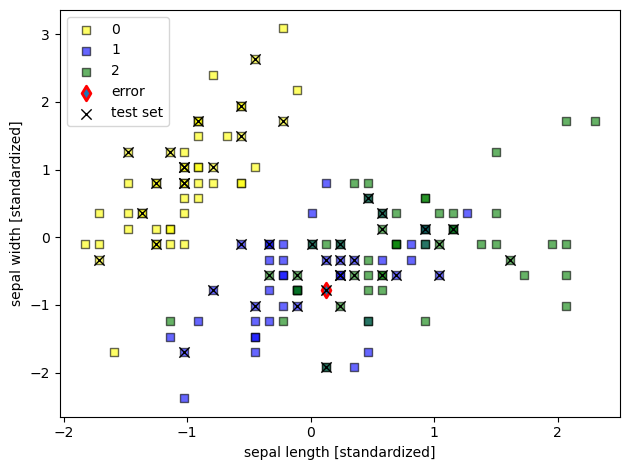

In [17]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

plot_decision_regions(X=X_combined_std, y=y_combined,
                      classifier=predictive_model, test_idx=range(105, 150))
plt.xlabel('sepal length [standardized]')
plt.ylabel('sepal width [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
# plt.savefig('./figures/iris_perceptron_scikit.png', dpi=300)
plt.show()

<a id='4_1'></a>
## Ülesanne 4.1

a) Muutke lahtris, kus toimub [klassifikaatori initsialiseerimine](#Pred) ära kasutatav klassifikaator, proovides läbi järgmised: 
* [Perceptron](https://scikit-learn.org/stable/modules/linear_model.html#perceptron)
* [LogisticRegression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
* [SVC ehk tugivektor klassifitseerimine](https://scikit-learn.org/stable/modules/svm.html#svm)
* [DecisionTree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier)

Millise meetodi puhul on täpsus (ka õigsus, väga lihtsustatud mõõt, aga siin sobib) suurim?


Meetodite täpsused:
* Perceptron - 0.9555555555555556 
* LogisticRegression - 0.9777777777777777
* SVC ehk tugivektor klassifitseerimine - 0.9777777777777777
* DecisionTree - 0.9777777777777777

Sama täpsus on kolmel meetodil, pertseptroni puhul on täpsus madalaim. 

b) Laadige alla eelmises ülesandes vaadeldud [loomaaia andmestik](https://archive.ics.uci.edu/ml/datasets/zoo). Võtke veerg `aquatic` ennustatavaks klassiks Y. Looge andmetabel *X*, millest on eemaldatud klassile vastav veerg `aquatic` ja mittearvuline veerg `type`. Kui see pole tehtud pandas *Dataframe* indeksiks, siis eemaldada ka mittearvuline ja unikaalsete väärtustega veerg `animal_name`.

Jagage andmed, nagu iiriste näites, treening- ja testandmeteks. Treenige a) osas mainitud  klassifikaatoreid ja leidke neist täpseim testandmete põhjal.

In [18]:
import pandas as pd
zoo_df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data",
                    index_col=0,
                    names=["hair", "feathers","eggs", "milk","airborne","aquatic", "predator", "toothed","backbone", "breathes", "venomous", "fins", "legs", "size", "domestic", "catsize", "type"])
Y = zoo_df.aquatic
X = zoo_df.drop(columns=['aquatic', 'type'])

# Jaga andmed treening- ja testandmeteks
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

# Normaliseeri andmed
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test) 

# Ennustavate mudelite loomine
predictive_model = Perceptron(max_iter=40, tol=0.001, eta0=0.1, random_state=0)
# predictive_model = LogisticRegression(solver='lbfgs') # actually a classification, not regression
# predictive_model = SVC(kernel='rbf') # Support Vector Classification. Tugivektor klassifitseerimine.
# predictive_model = DecisionTreeClassifier()

# Mudeli treenime
predictive_model.fit(X_train_std, Y_train)

# Testandmete ennustused
Y_pred = predictive_model.predict(X_test_std)

# Mudeli ennustustäpsus
accuracy_score(Y_test, Y_pred)


0.9032258064516129

Meetodite täpsused:
* Perceptron - 0.9032258064516129 
* LogisticRegression - 0.8387096774193549
* SVC ehk tugivektor klassifitseerimine - 0.8064516129032258 
* DecisionTree - 0.8387096774193549

Täpseim meetod on pertseptron.

<a id='Meetodeid'></a>
# Klassifitseerimismeetodeid: pertseptronid, lineaarne regressioon, tugivektor masinad ja otsustuspuud


Siin anname ülevaate mõningate klassifitseerimismeetodite teooriast. Kuigi scikit-learn võimaldab neid kasutada "musta kastina" on teooria ja vastava matemaatika ning algoritmide  tundmine tihti kasulik ja vajalik. Põhjalikum seletus kursuse põhiõpikust inglise keeles on siin: [Single-Layer Neural Networks and Gradient Descent](https://sebastianraschka.com/Articles/2015_singlelayer_neurons.html).


## Pertseptron


<img src="https://sebastianraschka.com/images/blog/2015/singlelayer_neural_networks_files/perceptron_neuron.png">

*Joonis 1. Neuron. S. Raschka, Python Machine Learning.* https://sebastianraschka.com/Articles/2015_singlelayer_neurons.html

<img src="https://sebastianraschka.com/images/blog/2015/singlelayer_neural_networks_files/perceptron_schematic.png">

*Joonis 2. Pertseptroni skeem. S.Raschka, Python Machine Learning.*

Summaarne sisend on arvutatud neuroni sisendväärtuste __x__ ja kaaluvektori **w** elementhaaval korrutise summana (vaadates vektoreid maatriksitena, saame selleks kasutada maatrikskorrutist):
$z = w_1 x_1 + ... w_m x_ m$

$w = \begin{bmatrix}
w_1  \\
...  \\
w_m   
\end{bmatrix},  
x = \begin{bmatrix}
x_1  \\
...  \\
x_m   
\end{bmatrix}$

Sisendväärtused vastavad närvivõrgu analoogias välisele stiimulile, kaalud neuroni dendriitide konfiguratsioonile ja summa on sisend aksonile, mis aktiveerub vastavalt aktivisatsioonifunktsioonile. 

In [19]:
# Tekitame juhuslikud pertseptroni kaalud w 4 sisendi jaoks
w = np.random.rand(4)
#w = np.ones(4)
print(w)

[0.25954964 0.53882232 0.74646745 0.41692929]


In [20]:
# Rakendame neid esimesele objektile iiriste andmestikust
X = iris.data

print(X[0])
z = w @ X[0].T
print(z)

[5.1 3.5 1.4 0.2]
4.338021544332068


Aktivisatsioonifunktsiooniks $\phi(z)$ kasutame siin lihtsat Heaviside (läve) funktsiooni, kus läveks on $\theta$:

$\phi(z) = \begin{cases}
1 & \text{kui $z \geq \theta$ } \\
0 & \text{muul juhul}
\end{cases}$

In [21]:
# Näiteks nii (theta=0)
y_pred = int(z>=0)
y_pred

1

Juhuslikud kaalud annavad loomulikult juhuslikke tulemusi. Juhitud  (supervised) õppimise käigus muudame me klassifikaatorit näiteobjektide põhjal. Antud juhul korrigeerime me kaale. Selleks on erinevaid meetodeid (geneetilised, evolutsioonilised, gradient descent), aga siin vaatame me vast kõige triviaalsemat võimalust, kus iga kaalu $w_j$ muudetakse $\Delta w_j$ võrra:

$w_j := w_j + \Delta w_j$

Korrektsioon $\Delta w_j$ leitakse triviaalselt:

$\Delta w_j = \eta (y-\hat{y}) x_j$

$\eta$: õppimiskiiruse konstant 0...1 vahel, $y$: tegelik väärtus, $\hat{y}$: ennustatud väärtus ehk $\phi(z)$.

In [22]:
# Näiteks esimese objekti ja klassi versicolor jaoks
y_versi = (y==1).astype(int)
eta = 0.02 # õppimiskiirus
delta_w = eta * (y_versi[0]-y_pred) * X[0] # NB! X[0] on reavektor, opereerime kõigi kaaludega korraga
print("Kaalude deltad:", delta_w)
w += delta_w
print("Muudetud kaalud:", w)

Kaalude deltad: [-0.102 -0.07  -0.028 -0.004]
Muudetud kaalud: [0.15754964 0.46882232 0.71846745 0.41292929]


In [23]:
# Kontrollime ennustustäpsust
y_preds = [int((w @ x.T)>=0) for x in X[:100]]
print(y_preds)
print("Täpsus:", sum(y_preds==y_versi[:100]) / len(y_preds))

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Täpsus: 0.5


In [24]:
# Tegelikult toimub õppimine loomulikult tsüklis
for x_i, y_i in zip(X[:100], y_versi[:100]):
    z = w @ x_i.T
    y_pred = int(z>=0)
    delta_w = eta * (y_i - y_pred) * x_i
    w += delta_w
print(w)

[-0.42445036  0.07282232  0.54046745  0.38892929]


In [25]:
# Ja testime oma tulemust (treening- ja testandmed on meil samad, mis poe üldiselt hea)
y_preds = [int((w @ x.T)>=0) for x in X[:100]]
print(y_preds)
print("Täpsus:", sum(y_preds==y_versi[:100]) / len(y_preds))


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Täpsus: 1.0


## Logistiline regressioon



<a id=#sigmoid></a>

Logistiline regressioon ([scikit-learn Logistic Regression](https://scikit-learn.org/stable/modules/linear_model.html)) põhineb rafineeritumal aktivisatsioonifunktsioonil ja õppimisreeglil kui eelpool vaadeldud triviaalne pertseptron. Siin ei ole väljundiks mitte nominaalne klass , vaid tõenäosus vahemikus 0..1 ja õppimine põhineb gradientlaskumisel: kui ennustus on vähem mööda, siis muudetakse kaale vähem, kui rohkem mööda, siis rohkem.

Summat  $z$ interpreteeritakse siin kui logaritmi sündmuse toimumise ja mittetoimumise tõenäosuste suhtest (tihti öeldakse näiteks, et šansid on kolm nelja vastu vms). Suhe tõenäosuse $p$ jaoks on $\frac{p}{1-p}$. Logaritm sellest on $logit(p) = \ln \frac{p}{1-p}$, mille omakorda võtame (meelevaldselt) võrdseks 
$$logit(p) = \ln \frac{p}{1-p} = z = w^T x$$. 

Avaldise  $\ln \frac{p}{1-p}$ teisendab tõenäosuseks tagasi **sigmoidfunktsioon** $$\phi(z)=\frac{1}{1+e^{-z}}$$, mida kasutame aktivisatsioonifunktsioonina.

Vt ka [Logistic Regression: Why sigmoid function?](https://sebastianraschka.com/faq/docs/logistic-why-sigmoid.html)

<img src=https://sebastianraschka.com/images/blog/2015/singlelayer_neural_networks_files/perceptron_gradient_descent_1.png></img>

*Joonis 3. Gradientlaskumine. S.Raschka, Python Machine Learning.*

Treenimisel lähtume gradientlaskumise meetodist, kus $\Delta \mathbf{w}$ leidmisel lähtume vähimruutude meetodi põhiselt defineeritud hinnafunktsioonist $J(w)$ (summeerime hinna üle kõigi treeningobjektide indeksitega $i$).

$$J(\mathbf{w})=\sum_i{(\phi(z^{(i)}) - y^{(i)})^2}$$

Korrektsioon kaalule leitakse $J(w)$ tuletise/gradiendi abil $$\Delta w_j = -\eta \frac{\partial{J}}{\partial{w_j}} = \eta \sum_i{(y^{(i)} - \phi(z^{(i)})) x_j^{(i)}}$$

Stohhastiline gradientlaskumine on eelmise versioon, mis muudab kaale inkrementaalselt elementhaaval.

Treenime logistilise regressiooni mudeli ja kuvame selle täpsuse.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=0)
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print("Logistilise regressiooni täpsus testandmetel:", lr_acc)

Logistilise regressiooni täpsus testandmetel: 0.9777777777777777


Logistilise regressiooni mudeli kaalud on listina kirjas atribuudis `coef_`.

In [27]:
lr.coef_

array([[-0.39548445,  0.83378421, -2.28886195, -0.97845885],
       [ 0.54310937, -0.29032956, -0.23226308, -0.65785485],
       [-0.14762492, -0.54345464,  2.52112503,  1.63631371]])

Kuvame need ilusalt andmeraamistikuna. Nagu näeme, on iga klassi jaoks oma võrrand oma kaaludega.

In [28]:
pd.DataFrame(lr.coef_, index=iris.target_names, columns=iris.feature_names)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,-0.395484,0.833784,-2.288862,-0.978459
versicolor,0.543109,-0.290330,-0.232263,-0.657855
virginica,-0.147625,-0.543455,2.521125,1.636314


Kui atribuudid on väga erinevatel skaaladel - erinev standardhälve, erinev maksimum jne - siis võivad logistiline regressioon ja pertseptron vajada andmete standardiseerimist, mida hakkame vaatama andmete eeltöötluse all.

## Tugivektor-masin (Support Vector Machine, SVM)

Tugivektor-masin ei maksimeeri mitte ainult ennustustäpsust vaid ka klasside eraldatust. St, et eraldav hüpertasand on lähimatest vastandmärgenditega treeningolemitest ehk tugivektoritest võrdsel ja maksimaalsel kaugusel.

<img src=https://upload.wikimedia.org/wikipedia/commons/thumb/7/72/SVM_margin.png/1024px-SVM_margin.png> </img>



*Joonis 4. Eesmärgiks on leida eraldav hüpertasand, mis on tugivektoritest st sellele hüpertasandile lähimatest olemitest maksimaalsel kaugusel. Antud näites on kaks sinisesse ja üks rohelisse klassi kuuluvat tugivektorit (Vikipeedia)*

See meetod töötab hästi kui dimensioone on palju, sest see teeb lineaarse eraldamise lihtsamaks.

Juhul kui andmed ei ole lineaarselt eraldatavad, siis kasutatakse andmete kujutist kõrgema dimensionaalsusega ruumi, kus need loodetavasti on lineaarselt eralduvad (*kernel trick*). Laialt kasutatud meetod selleks on *Radial Basis Function kernel, RBF kernel*.

## Otsustuspuu




Otsustuspuu määrab objekti klassi, rakendades sellele objektile puud mööda allapoole liikudes järjest uusi tingimusi.

Otsustuspuud esitab visuaalselt mooduli `sklearn.tree` funktsioon `plot_tree()`, tekstina sama mooduli funktsioon `export_text()`.



<!--Kahjuks ei ole GraphViz TTÜ arvutitesse installeeritud. Õnneks võimaldavad veebiliidesed, nagu
https://dreampuf.github.io/GraphvizOnline/ dot faili teksti põhjal puud genereerida. Allolevas väljundlahtris leiduv tekst tuleb copy-paste abil veebiaknasse kopeerida, misjärel on võimalik genereeritud pilt salvestada.-->



In [ ]:
import sklearn
from sklearn import tree

dt = DecisionTreeClassifier(criterion='entropy')
# Error?
dt.fit(X_train_std, y_train)
#dot = sklearn.tree.export_graphviz(dt, out_file=None)
#print(dot)

plt = sklearn.tree.plot_tree(dt, feature_names=iris.feature_names, fontsize=6)

ValueError: Number of labels=105 does not match number of samples=70

In [ ]:
# vanemad sklearn versioonid ei pruugi puu kuvamise funktsionaalsust toetada
sklearn.__version__

In [ ]:
print(sklearn.tree.export_text(dt, feature_names=iris.feature_names))

Otsustuspuu genereerimisel leitakse atribuut, mis jaotab andmestiku suurima informatsiooni kasvu (IG, information gain) alusel.

$$ IG(D_p, f) = I(D_p) - \sum_{j=1..m} \frac{|D_j|}{|D_p|}I(D_j)$$

Kus $f$ on kandidaatatribuut jaotamiseks (*feature*, reaalarvulise atribuudi korral on seal ka lävi), $D_p$ on ülemandmestik, $D_j$ on sellest $f$ alusel tekkivad $m$ alamandmestikku. $|D_p|$ ja $|D_j|$ on objektide arvud andmestikes. $I(D)$ on ebapuhtuse mõõt. Eesmärgiks on leida selline $f$, mille puhul $IG(D_p, f)$ on maksimaalne, st alamandmestike summaarne ebapuhtus $\sum_{j=1..m} \frac{|D_j|}{|D_p|}I(D_j)$ on minimaalne.

Erinevad meetrikad ebapuhtuse mõõtmiseks on näiteks entroopia $I_H$ ja Gini ebapuhtus $I_G$. 

$$ I_H(t) = - \sum_{i=1..c} p(i|t) \log_{2} p(i|t)$$

$p(i|t)$ on klassi $i$ kuuluvate elementide suhtarv (vahemikus 0..1) sõlmes $t$.

$$ I_G(t) = \sum_{i=1..c} p(i|t) (1-p(i|t))$$

Gini ebapuhtust saab interpreteerida vääriti klassifitseerimise tõenäosusena.

In [ ]:
def entropy(p):
    return -np.sum(p * np.log2(p))

In [ ]:
entropy([0.33, 0.33, 0.33])

In [ ]:
def gini(p):
    return np.sum(p * (1-p))

In [ ]:
gini(np.array([0.01, 0.01, 0.98]))

<a id='4_2'></a>
## Ülesanne 4.2 

a.) Näidake, et asendades $z = \ln \frac{p}{1-p}$ [sigmoidfunktsiooni](#sigmoid) $\phi(z)=\frac{1}{1+e^{-z}}$ saame väärtuseks tõenäosuse $p$. Pange tuletuskäik siia kirja, kasutades dollarisümbolite vahel LaTeX-i matemaatilist notatsiooni. Vt näiteks https://www.overleaf.com/learn/latex/Mathematical_expressions , ka tavaline Google otsing LaTeX+probleem annab tavaliselt tulemuseks mõistliku StackExchange vastuse.

$\phi(p)=\frac{1}{1+e^{-\ln \frac{p}{1-p}}}=\frac{1}{1+e^{\ln \frac{1-p}{p}}} = \frac{1}{1+\frac{1-p}{p}} = \frac{1}{\frac{p + 1-p}{p}} = \frac{1}{\frac{1}{p}} = p$


b.) Kuvada ülesande 4.1.b loomaaia andmestiku põhjal otsustuspuu (`sklearn.tree.export_text`). Milline on esimene tingimus puus, mille alusel veeloomaks olekut kontrollitakse?

In [ ]:
dt.fit(X_train_std, Y_train)

print(sklearn.tree.export_text(dt, feature_names=X.columns))

# Esimene tingimus, mille alusel veeloomaks olekut kontrollitakse on, kas loom hingab (breathes)